## PlantVillage (Potato) + PatchCore 이상 탐지

**PlantVillage** 감자 잎 서브셋에서 **정상 잎만** Memory Bank를 만들고,
겹무늬병·역병을 PatchCore로 탐지하는 예제입니다.

전체 38클래스·5만 장은 용량이 커서 **Potato 3클래스만** 소량 샘플링합니다.

| 단계 | 내용 |
|------|------|
| 1 | 환경·import |
| 2 | PlantVillage Potato 로드 (클래스당 소수 장) |
| 3 | EDA |
| 4 | Feature + Coreset + Memory Bank |
| 5 | Test · AUROC · heatmap |

**선택한 클래스**
- `Potato___healthy` — 정상 (train Memory Bank)
- `Potato___Early_blight` — 겹무늬병 (test 이상)
- `Potato___Late_blight` — 역병 (test 이상)

> **실행 환경**: Google Colab (GPU 권장) 또는 로컬 Jupyter  
> **데이터**: [PlantVillage](https://github.com/spMohanty/PlantVillage-Dataset) Potato 서브셋 (약 150장)  
> **백본**: Wide ResNet50-2 (ImageNet 사전학습)


### 1. 환경 설정

> Colab/로컬 감지, 패키지, import, `device` 설정


In [1]:
# ========== 실행 환경 감지 ==========
# Google Colab이면 IN_COLAB=True
# 로컬 Jupyter면 GitHub에서 Potato 이미지만 캐시 폴더로 다운로드
try:
    import google.colab
    IN_COLAB = True
    print('Google Colab 환경')
except ImportError:
    IN_COLAB = False
    print('로컬 Jupyter 환경')


로컬 Jupyter 환경


In [2]:
# ========== 패키지 설치 안내 ==========
# %pip install -q torch torchvision scikit-learn seaborn datasets huggingface_hub
# py -3.11 -m pip install torch torchvision scikit-learn seaborn datasets huggingface_hub pillow matplotlib


In [3]:
# ========== 라이브러리 import · 전역 설정 ==========
import logging
import time
import urllib.error
import urllib.request
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from urllib.parse import quote

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from datasets import ClassLabel, Dataset, Features, Value
from datasets import Image as HFImage
from huggingface_hub import hf_hub_download
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from torch.utils.data import DataLoader, Dataset as TorchDataset
from torchvision.models import Wide_ResNet50_2_Weights, wide_resnet50_2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')


def setup_korean_font() -> str:
    """matplotlib 한글 제목/축 라벨 깨짐 방지."""
    available = {f.name for f in fm.fontManager.ttflist}
    for name in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans KR']:
        if name in available:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False
            return name
    plt.rcParams['axes.unicode_minus'] = False
    return 'DejaVu Sans'


logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
print(f'한글 폰트: {setup_korean_font()}')

RNG = np.random.default_rng(42)
torch.manual_seed(42)


device: cuda
한글 폰트: Malgun Gothic


### 2. PlantVillage 로드 (Potato 3클래스)

> HuggingFace 공식 80/20 분할 목록 → GitHub에서 **감자 이미지만** 다운로드  
> train: 정상만 / test: 정상 + 겹무늬병 + 역병  
> **EDA·PatchCore 전에 이 코드 셀을 실행** (`train_ds`, `test_ds` 생성)


In [4]:
# ========== PlantVillage (Potato 서브셋) 로드 ==========
PV_HF_ID = 'mohanty/PlantVillage'
GITHUB_RAW = 'https://raw.githubusercontent.com/spMohanty/PlantVillage-Dataset/master'
CACHE_DIR = Path('./data/plantvillage_potato')

SELECTED_CLASSES = [
    'Potato___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
]
CLASS_DISPLAY = {
    'Potato___healthy': '정상',
    'Potato___Early_blight': '겹무늬병',
    'Potato___Late_blight': '역병',
}
LABEL_NAMES = {0: 'healthy', 1: 'diseased'}

MAX_TRAIN_HEALTHY = 80
MAX_TEST_PER_CLASS = 24
USER_AGENT = {'User-Agent': 'PlantVillage-PatchCore-PoC/1.0'}


def _read_split_file(filename: str) -> list[str]:
    path = hf_hub_download(
        repo_id=PV_HF_ID,
        repo_type='dataset',
        filename=filename,
    )
    return Path(path).read_text(encoding='utf-8').splitlines()


def _class_from_relpath(relpath: str) -> str | None:
    parts = relpath.strip().split('/')
    if len(parts) < 4:
        return None
    return parts[2]


def sample_split_paths(
    lines: list[str],
    class_names: list[str],
    max_per_class: dict[str, int],
    rng: np.random.Generator,
) -> list[str]:
    buckets: dict[str, list[str]] = {c: [] for c in class_names}
    for line in lines:
        rel = line.strip()
        cls = _class_from_relpath(rel)
        if cls in buckets:
            buckets[cls].append(rel)

    picked: list[str] = []
    for cls in class_names:
        paths = buckets[cls]
        cap = max_per_class.get(cls, 0)
        if cap <= 0 or not paths:
            continue
        order = rng.permutation(len(paths))
        picked.extend(paths[i] for i in order[: min(cap, len(paths))])
    return picked


def _download_one(relpath: str, retries: int = 3) -> Path:
    dest = CACHE_DIR / relpath
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and dest.stat().st_size > 1000:
        return dest

    url = f'{GITHUB_RAW}/{quote(relpath, safe="/")}'
    last_exc: Exception | None = None
    for attempt in range(1, retries + 1):
        req = urllib.request.Request(url, headers=USER_AGENT)
        tmp = dest.with_suffix(dest.suffix + '.part')
        try:
            with urllib.request.urlopen(req, timeout=30) as resp:
                tmp.write_bytes(resp.read())
            tmp.replace(dest)
            return dest
        except (urllib.error.URLError, TimeoutError, OSError) as exc:
            last_exc = exc
            if tmp.exists():
                tmp.unlink(missing_ok=True)
            time.sleep(0.4 * attempt)
    raise RuntimeError(f'다운로드 실패: {relpath} ({last_exc})') from last_exc


def download_images(relpaths: list[str], max_workers: int = 8) -> list[Path]:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    paths: list[Path] = [Path()] * len(relpaths)
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {pool.submit(_download_one, rel): i for i, rel in enumerate(relpaths)}
        for fut in as_completed(futures):
            i = futures[fut]
            paths[i] = fut.result()
    return paths


def records_from_paths(relpaths: list[str], local_paths: list[Path]) -> list[dict]:
    rows = []
    for rel, local in zip(relpaths, local_paths):
        cls = _class_from_relpath(rel)
        rows.append({
            'image': str(local),
            'label': 0 if cls == 'Potato___healthy' else 1,
            'defect_type': cls,
            'mask_path': '',
        })
    return rows


print('PlantVillage 공식 train/test 분할 목록 다운로드 중...')
train_lines = _read_split_file('splits/color_train.txt')
test_lines = _read_split_file('splits/color_test.txt')

train_rel = sample_split_paths(
    train_lines,
    SELECTED_CLASSES,
    {
        'Potato___healthy': MAX_TRAIN_HEALTHY,
        'Potato___Early_blight': 0,
        'Potato___Late_blight': 0,
    },
    RNG,
)
test_rel = sample_split_paths(
    test_lines,
    SELECTED_CLASSES,
    {c: MAX_TEST_PER_CLASS for c in SELECTED_CLASSES},
    RNG,
)

print(f'이미지 다운로드 중... train {len(train_rel)}장 + test {len(test_rel)}장')
train_files = download_images(train_rel)
test_files = download_images(test_rel)

features = Features({
    'image': HFImage(),
    'label': ClassLabel(names=['healthy', 'diseased']),
    'defect_type': Value('string'),
    'mask_path': Value('string'),
})
train_ds = Dataset.from_list(records_from_paths(train_rel, train_files), features=features)
test_ds = Dataset.from_list(records_from_paths(test_rel, test_files), features=features)

print(f'데이터셋: PlantVillage Potato 서브셋 ({PV_HF_ID} 분할 목록 + GitHub 이미지)')
print(f'  train (healthy only): {len(train_ds)}장')
print(f'  test:  {len(test_ds)}장')
test_labels = np.array(test_ds['label'])
for lbl in [0, 1]:
    print(f'  test {LABEL_NAMES[lbl]}: {(test_labels == lbl).sum()}장')
print('  test 세부 클래스:')
for cls in SELECTED_CLASSES:
    cnt = sum(1 for name in test_ds['defect_type'] if name == cls)
    print(f'    {CLASS_DISPLAY[cls]:6s} ({cls}): {cnt}장')


PlantVillage 공식 train/test 분할 목록 다운로드 중...
이미지 다운로드 중... train 80장 + test 72장
데이터셋: PlantVillage Potato 서브셋 (mohanty/PlantVillage 분할 목록 + GitHub 이미지)
  train (healthy only): 80장
  test:  72장
  test healthy: 24장
  test diseased: 48장
  test 세부 클래스:
    정상     (Potato___healthy): 24장
    겹무늬병   (Potato___Early_blight): 24장
    역병     (Potato___Late_blight): 24장


### 3. EDA (탐색적 데이터 분석)

> 장수·병해 유형·해상도 통계 및 샘플 이미지 그리드


In [5]:
# ========== EDA — 메타 수집·통계 출력 ==========
# 학습 전 데이터 분포 확인 (병해 유형, 해상도)

def row_to_pil(row, key: str = 'image') -> Image.Image:
    """Dataset 행의 image 컬럼 → RGB PIL."""
    img = row[key]
    if img is None:
        return None
    if isinstance(img, Image.Image):
        return img.convert('RGB')
    return Image.fromarray(np.asarray(img)).convert('RGB')


def collect_meta(split_ds) -> dict:
    """인덱스 순회하며 라벨·병해명·(W,H)·마스크 경로 존재 여부 수집."""
    defects, sizes, labels, has_mask = [], [], [], []
    for i in range(len(split_ds)):
        row = split_ds[i]
        labels.append(int(row['label']))
        defects.append(row['defect_type'])
        sizes.append(row_to_pil(row).size)
        has_mask.append(bool(row.get('mask_path')))
    return {'labels': labels, 'defects': defects, 'sizes': sizes, 'has_mask': has_mask}


meta_train = collect_meta(train_ds)
meta_test = collect_meta(test_ds)
print('=== Train ===')
print('  장수:', len(train_ds))
print('  defect_type:', Counter(meta_train['defects']))
print('  해상도 unique:', Counter(meta_train['sizes']))
print('=== Test ===')
print('  장수:', len(test_ds))
print('  label:', Counter(meta_test['labels']))
print('  defect_type:', Counter(meta_test['defects']))
print('  마스크 보유(병해 GT):', sum(meta_test['has_mask']), '(PlantVillage는 픽셀 마스크 없음)')


=== Train ===
  장수: 80
  defect_type: Counter({'Potato___healthy': 80})
  해상도 unique: Counter({(256, 256): 80})
=== Test ===
  장수: 72
  label: Counter({1: 48, 0: 24})
  defect_type: Counter({'Potato___healthy': 24, 'Potato___Early_blight': 24, 'Potato___Late_blight': 24})
  마스크 보유(병해 GT): 0 (PlantVillage는 픽셀 마스크 없음)


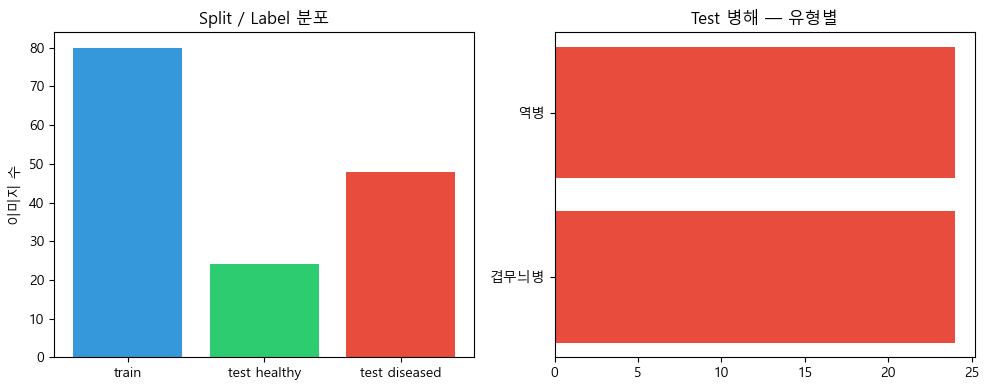

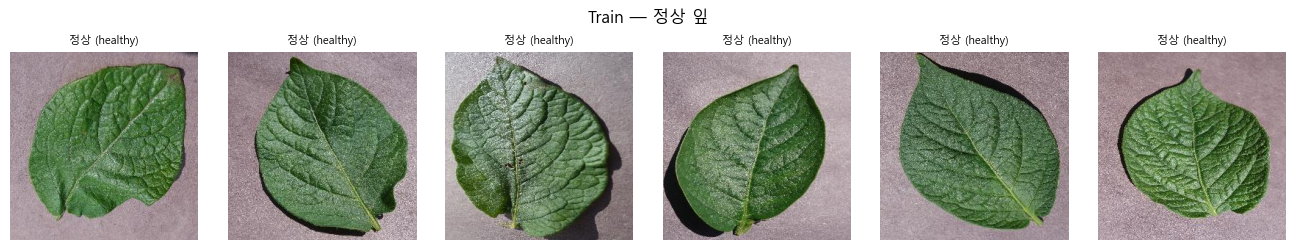

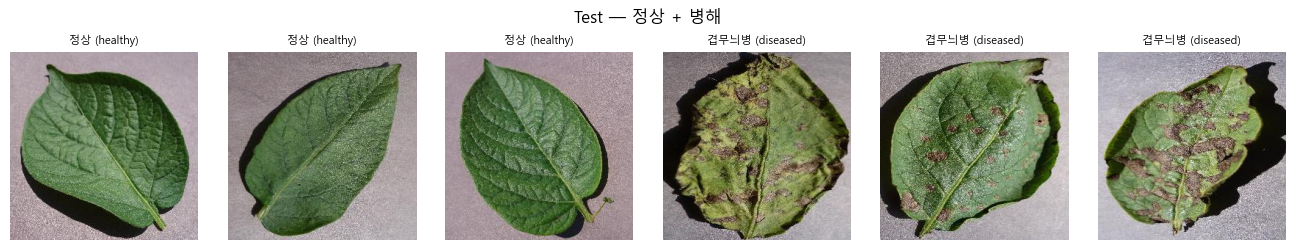

In [6]:
# ========== EDA — 분포 차트·샘플 그리드 ==========
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['train'], [len(train_ds)], color='#3498db')
test_counts = [
    sum(1 for l in meta_test['labels'] if l == 0),
    sum(1 for l in meta_test['labels'] if l == 1),
]
axes[0].bar(['test healthy', 'test diseased'], test_counts, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Split / Label 분포')
axes[0].set_ylabel('이미지 수')

defect_cnt = Counter(
    CLASS_DISPLAY.get(d, d)
    for d, l in zip(meta_test['defects'], meta_test['labels']) if l == 1
)
if defect_cnt:
    axes[1].barh(list(defect_cnt.keys()), list(defect_cnt.values()), color='#e74c3c')
axes[1].set_title('Test 병해 — 유형별')
plt.tight_layout()
plt.show()


def show_grid(rows, title, n=6):
    """행 리스트를 1×n 그리드로 표시 (제목에 병해 유형·라벨)."""
    n = min(n, len(rows))
    fig, axs = plt.subplots(1, n, figsize=(2.2 * n, 2.5))
    if n == 1:
        axs = [axs]
    for ax, row in zip(axs, rows):
        ax.imshow(row_to_pil(row))
        dtype = CLASS_DISPLAY.get(row['defect_type'], row['defect_type'])
        ax.set_title(f"{dtype} ({LABEL_NAMES[int(row['label'])]})", fontsize=8)
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_grid([train_ds[i] for i in range(min(6, len(train_ds)))], 'Train — 정상 잎')
ab_idx = [i for i in range(len(test_ds)) if int(test_ds[i]['label']) == 1][:3]
ok_idx = [i for i in range(len(test_ds)) if int(test_ds[i]['label']) == 0][:3]
show_grid([test_ds[i] for i in ok_idx + ab_idx], 'Test — 정상 + 병해')


### 4. PatchCore 구현

> Wide ResNet50-2 패치 feature → Coreset Memory Bank → NN 이상 점수


In [7]:
# ========== PatchCore 백본·하이퍼파라미터 ==========
# INPUT 256×256 → feature map 약 32×32 → 이미지당 ~1024 패치 × 80장 ≈ 8.2만 패치
INPUT_SIZE = (256, 256)
BATCH_SIZE = 8
CORESET_RATIO = 0.01       # train 패치의 1% → Memory Bank 약 820개
MAX_CORESET_SIZE = 1200    # CPU 시간 목표용 상한
MAX_TRAIN_PATCHES = None   # 예: 30_000 으로 줄이면 Coreset 더 빠름 (정확도↓)
NN_CHUNK_SIZE = 4096       # test 시 cdist 청크 (VRAM 절약)
GAUSSIAN_SIGMA = 4.0       # Anomaly map 스무딩

transform = T.Compose([
    T.Resize(INPUT_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class PlantVillageTorchDataset(TorchDataset):
    """HF split → 모델 입력 텐서 + 라벨 + (선택) 픽셀 마스크."""

    def __init__(self, hf_split, include_mask: bool = False):
        self.split = hf_split
        self.include_mask = include_mask

    def __len__(self):
        return len(self.split)

    def __getitem__(self, idx):
        row = self.split[idx]
        x = transform(row_to_pil(row))
        label = int(row['label'])
        defect = row['defect_type']
        mask_t = torch.zeros(1, *INPUT_SIZE)
        mpath = row.get('mask_path') or ''
        if self.include_mask and mpath:
            m = Image.open(mpath).convert('L').resize(INPUT_SIZE, Image.NEAREST)
            mask_t = T.ToTensor()(m)
        return x, label, defect, mask_t


class FeatureExtractor(nn.Module):
    """
    PatchCore 백본: Wide ResNet50-2
    - layer2 (512ch) + layer3 (1024ch, layer2 크기로 align) → concat 1536ch/feature map
    - forward 출력: [B, 1536, H, W] — 각 spatial 위치가 하나의 패치 임베딩
    """

    def __init__(self):
        super().__init__()
        backbone = wide_resnet50_2(weights=Wide_ResNet50_2_Weights.IMAGENET1K_V1)
        self.backbone = backbone
        self.hooks: list[torch.Tensor] = []
        backbone.layer2.register_forward_hook(self._hook)
        backbone.layer3.register_forward_hook(self._hook)

    def _hook(self, _module, _inp, out):
        self.hooks.append(out)

    @torch.no_grad()
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        self.hooks.clear()
        _ = self.backbone(x)
        f2, f3 = self.hooks[0], self.hooks[1]
        f3 = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
        return torch.cat([f2, f3], dim=1)


feature_extractor = FeatureExtractor().to(device).eval()
print('입력:', INPUT_SIZE, '| feature channels:', feature_extractor(
    torch.randn(1, 3, *INPUT_SIZE, device=device)
).shape[1])


Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to C:\Users\storm/.cache\torch\hub\checkpoints\wide_resnet50_2-95faca4d.pth


100%|██████████| 132M/132M [00:16<00:00, 8.47MB/s] 


입력: (256, 256) | feature channels: 1536


In [8]:
# ========== Patch Feature 추출 (train → Memory Bank 원본) ==========

@torch.no_grad()
def patch_features_from_batch(x: torch.Tensor) -> torch.Tensor:
    """[B,3,H,W] → feature map → [B*H*W, 1536] 모든 패치 벡터."""
    emb = feature_extractor(x)
    b, c, h, w = emb.shape
    return emb.permute(0, 2, 3, 1).reshape(-1, c)


@torch.no_grad()
def extract_patch_features(loader: DataLoader) -> torch.Tensor:
    """전체 loader 순회, 패치를 CPU에 누적 (Coreset 입력)."""
    feats = []
    for batch in loader:
        x = batch[0].to(device)
        feats.append(patch_features_from_batch(x).cpu())
    return torch.cat(feats, dim=0)


train_loader = DataLoader(
    PlantVillageTorchDataset(train_ds),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
print('train 패치 특징 추출 중...')
train_features = extract_patch_features(train_loader)

if MAX_TRAIN_PATCHES and train_features.shape[0] > MAX_TRAIN_PATCHES:
    idx = RNG.choice(train_features.shape[0], MAX_TRAIN_PATCHES, replace=False)
    train_features = train_features[idx]
    print(f'패치 무작위 축소: {MAX_TRAIN_PATCHES}')

print('train 패치 수:', train_features.shape[0], '| dim:', train_features.shape[1])
k_est = min(int(train_features.shape[0] * CORESET_RATIO), MAX_CORESET_SIZE)
print(f'예상 Coreset 크기: ~{k_est} (다음 Coreset 단계에서 구축)')


train 패치 특징 추출 중...
train 패치 수: 81920 | dim: 1536
예상 Coreset 크기: ~819 (다음 Coreset 단계에서 구축)


In [9]:
# ========== Memory Bank — Greedy Coreset (PatchCore 논문) ==========
# PatchCore 논문과 동일: 매 iteration
#   dist[i] = min_{{j in S}} ||f_i - f_j||,  다음 추가 argmax_i dist[i]
# 구현: torch.cdist(전체 패치, 선택집합 S).min(dim=1)
#

def greedy_coreset(
    features: torch.Tensor,
    sampling_ratio: float,
    max_size: int | None = MAX_CORESET_SIZE,
) -> torch.Tensor:
    n = features.shape[0]
    k = max(1, int(n * sampling_ratio))
    if max_size is not None:
        k = min(k, max_size)

    coreset_dev = device if device.type == 'cuda' else torch.device('cpu')
    feats = features.float().to(coreset_dev)
    selected = [int(RNG.integers(0, n))]

    for step in range(1, k):
        sel = feats[selected]
        dist = torch.cdist(feats, sel).min(dim=1).values
        for idx in selected:
            dist[idx] = -1.0
        selected.append(int(dist.argmax().item()))
        if step % 25 == 0 or step == k - 1:
            print(f'  coreset 진행: {step}/{k - 1}', end='\r')

    coreset = feats[selected].cpu()
    print(f'\nCoreset: {len(selected)} / {n} ({100 * len(selected) / n:.1f}%) | device={coreset_dev}')
    return coreset


memory_bank = greedy_coreset(train_features, CORESET_RATIO, max_size=MAX_CORESET_SIZE)
print('Memory Bank shape:', tuple(memory_bank.shape))

#   [소요 시간 · 파이프라인 병목]
#   GPU · CORESET_RATIO=0.01 · k≈820: 약 1~2분
#   CPU only · k≈820: 약 10~15분


  coreset 진행: 818/818
Coreset: 819 / 81920 (1.0%) | device=cuda
Memory Bank shape: (819, 1536)


In [10]:
# ========== Patch NN 거리 · Anomaly Map 유틸 ==========
# 추론: 각 test 패치 → Memory Bank 최근접 이웃 Euclidean 거리
# image-level score = 패치 거리의 max (가장 이상한 위치)


@torch.no_grad()
def patch_nearest_neighbor_scores(
    patch_feats: torch.Tensor,
    bank: torch.Tensor,
    chunk_size: int = NN_CHUNK_SIZE,
) -> torch.Tensor:
    scores = []
    bank = bank.float()
    for start in range(0, len(patch_feats), chunk_size):
        chunk = patch_feats[start : start + chunk_size].float()
        d = torch.cdist(chunk, bank)
        scores.append(d.min(dim=1).values)
    return torch.cat(scores)


def scores_to_anomaly_map(
    scores: torch.Tensor,
    feat_hw: tuple[int, int],
    out_size: tuple[int, int] = INPUT_SIZE,
    sigma: float = GAUSSIAN_SIGMA,
) -> np.ndarray:
    """패치 격자 [h,w] → bilinear 업샘플 → Gaussian blur → 0~1 정규화."""
    h, w = feat_hw
    amap = scores.reshape(h, w).numpy()
    t = torch.from_numpy(amap)[None, None].float()
    t = F.interpolate(t, size=out_size, mode='bilinear', align_corners=False)
    if sigma > 0:
        k = int(4 * sigma + 1) | 1
        x = torch.arange(k, dtype=torch.float32) - k // 2
        g = torch.exp(-0.5 * (x / sigma) ** 2)
        g = (g / g.sum())
        t = F.conv2d(t, g[None, None, None, :], padding=(0, k // 2))
        t = F.conv2d(t, g[None, None, :, None], padding=(k // 2, 0))
    amap = t.squeeze().numpy()
    return (amap - amap.min()) / (amap.max() - amap.min() + 1e-8)


@torch.no_grad()
def predict_image(x: torch.Tensor) -> tuple[float, np.ndarray, tuple[int, int]]:
    emb = feature_extractor(x)
    _, _, fh, fw = emb.shape
    patches = emb.permute(0, 2, 3, 1).reshape(-1, emb.shape[1]).cpu()
    scores = patch_nearest_neighbor_scores(patches, memory_bank)
    amap = scores_to_anomaly_map(scores, (fh, fw))
    return float(scores.max().item()), amap, (fh, fw)


### 5. Test 추론 · Anomaly Map 시각화

> 전 test 이미지 점수화, AUROC, heatmap 예시


In [11]:
# ========== Test 전체 추론 ==========

test_loader = DataLoader(
    PlantVillageTorchDataset(test_ds, include_mask=True),
    batch_size=1,
    shuffle=False,
)

image_scores, gt_labels, gt_masks, pred_maps = [], [], [], []

print('test 추론 중...')
for x, label, defect, mask_t in test_loader:
    score, amap, _ = predict_image(x.to(device))
    image_scores.append(score)
    gt_labels.append(int(label.item()))
    gt_masks.append(mask_t.squeeze().numpy())
    pred_maps.append(amap)

image_scores = np.asarray(image_scores, dtype=np.float64).ravel()
gt_labels = np.asarray(gt_labels, dtype=np.int64).ravel()
print('image score — healthy mean:', image_scores[gt_labels == 0].mean(),
      '| diseased mean:', image_scores[gt_labels == 1].mean())


test 추론 중...
image score — healthy mean: 5.837114691734314 | diseased mean: 6.231780499219894


Image-level AUROC: 0.7899


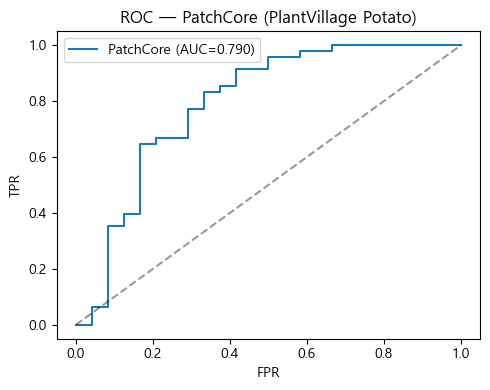

In [12]:
# ========== Image-level AUROC · ROC ==========
# 병해일수록 score↑ 가정 → roc_auc_score(gt, score) 그대로 사용

img_auc = roc_auc_score(gt_labels, image_scores)
fpr, tpr, _ = roc_curve(gt_labels, image_scores)
print(f'Image-level AUROC: {img_auc:.4f}')

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'PatchCore (AUC={img_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC — PatchCore (PlantVillage Potato)')
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
# ========== Pixel-level AUROC ==========
# PlantVillage는 병반 픽셀 마스크가 없어 기본적으로 스킵됩니다.

pix_scores, pix_gt = [], []
for amap, mask, lbl in zip(pred_maps, gt_masks, gt_labels):
    if lbl == 1 and mask.max() > 0:
        pix_scores.append(amap.flatten())
        pix_gt.append((mask > 0.5).astype(np.uint8).flatten())

if pix_scores:
    pix_auc = roc_auc_score(np.concatenate(pix_gt), np.concatenate(pix_scores))
    print(f'Pixel-level AUROC (defect only): {pix_auc:.4f}')
else:
    print('Pixel AUROC: PlantVillage는 GT 마스크가 없어 스킵')


Pixel AUROC: PlantVillage는 GT 마스크가 없어 스킵


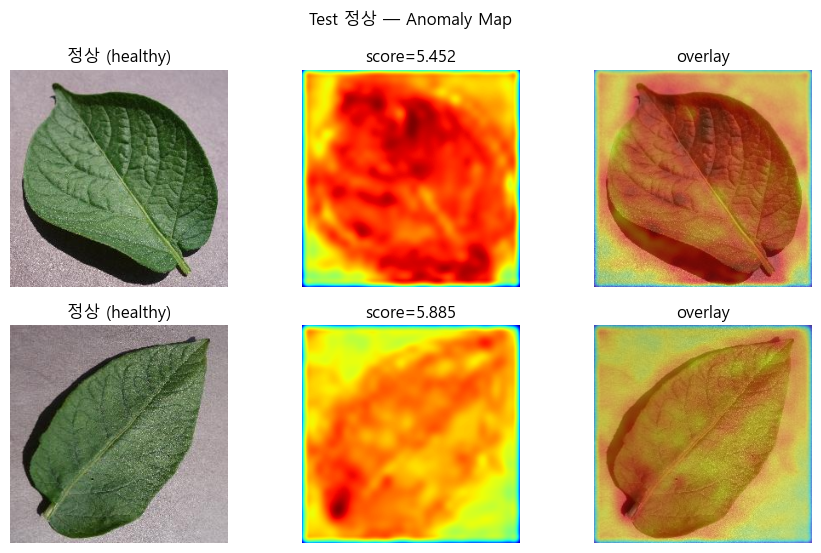

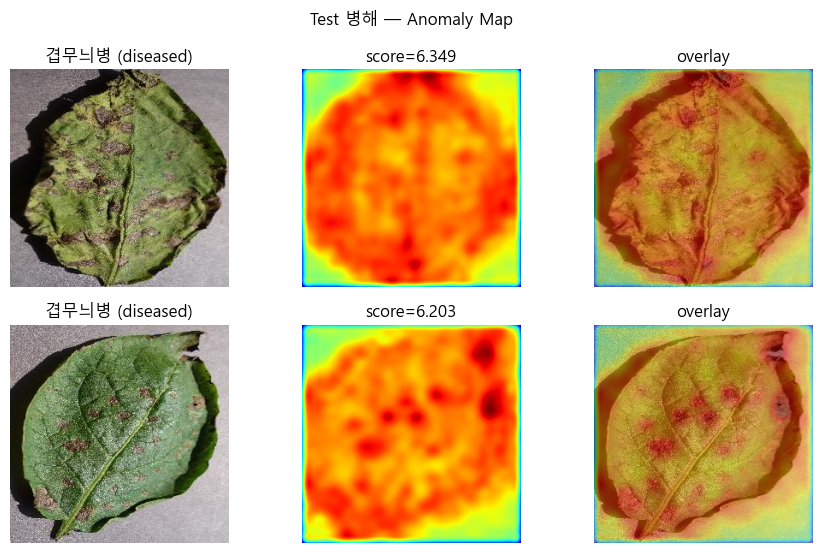

In [14]:
# ========== Anomaly Map 시각화 (정상 vs 병해 예시) ==========
# 각 행: 원본 | jet heatmap | overlay (재추론하므로 시간 소요)

def show_anomaly_examples(indices, title):
    n = len(indices)
    fig, axes = plt.subplots(n, 3, figsize=(9, 2.8 * n))
    if n == 1:
        axes = axes[None, :]
    for row, idx in enumerate(indices):
        x, label, defect, _ = test_loader.dataset[idx]
        score, amap, _ = predict_image(x.unsqueeze(0).to(device))
        img = x.permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        dtype = CLASS_DISPLAY.get(defect, defect)
        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f'{dtype} ({LABEL_NAMES[label]})')
        axes[row, 1].imshow(amap, cmap='jet')
        axes[row, 1].set_title(f'score={score:.3f}')
        axes[row, 2].imshow(img)
        axes[row, 2].imshow(amap, cmap='jet', alpha=0.5)
        axes[row, 2].set_title('overlay')
        for c in range(3):
            axes[row, c].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


ok_show = [i for i in range(len(test_ds)) if gt_labels[i] == 0][:2]
ng_show = [i for i in range(len(test_ds)) if gt_labels[i] == 1][:2]
show_anomaly_examples(ok_show, 'Test 정상 — Anomaly Map')
show_anomaly_examples(ng_show, 'Test 병해 — Anomaly Map')


### 6. 정리

| 항목 | 설정 |
|------|------|
| 데이터 | PlantVillage Potato — train 정상 80 / test 클래스당 24장 |
| Coreset | ratio 1%, max 1200, 논문 greedy |
| 픽셀 AUROC | PlantVillage는 GT 마스크가 없어 스킵 |
| CPU Coreset | k≈820 기준 약 10~15분 |

**다음 단계**
- `SELECTED_CLASSES`를 토마토·사과 등으로 바꿔 재실험
- train 정상 장수를 늘리면 Memory Bank가 더 안정적
- 병반 위치는 heatmap overlay로 정성적으로 확인

**참고**
- [PlantVillage Dataset (GitHub)](https://github.com/spMohanty/PlantVillage-Dataset)
- [PatchCore (Roth et al., CVPR 2022)](https://arxiv.org/abs/2106.08265)
